In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [9]:
df = pd.read_csv("data.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
df.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [13]:
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [14]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [15]:
df['LotFrontage']= df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [16]:
df.isnull().sum()


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

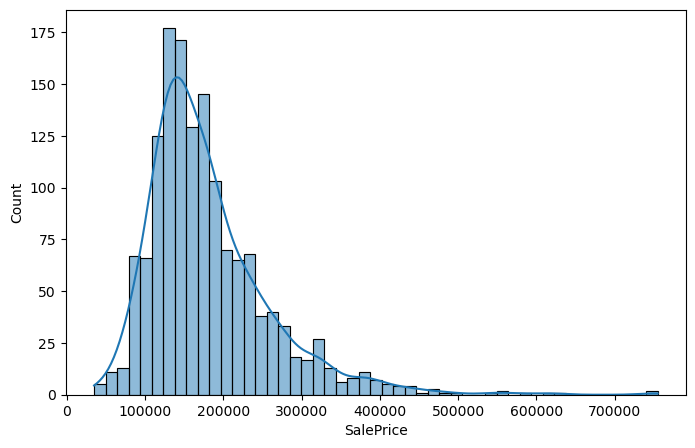

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.show()

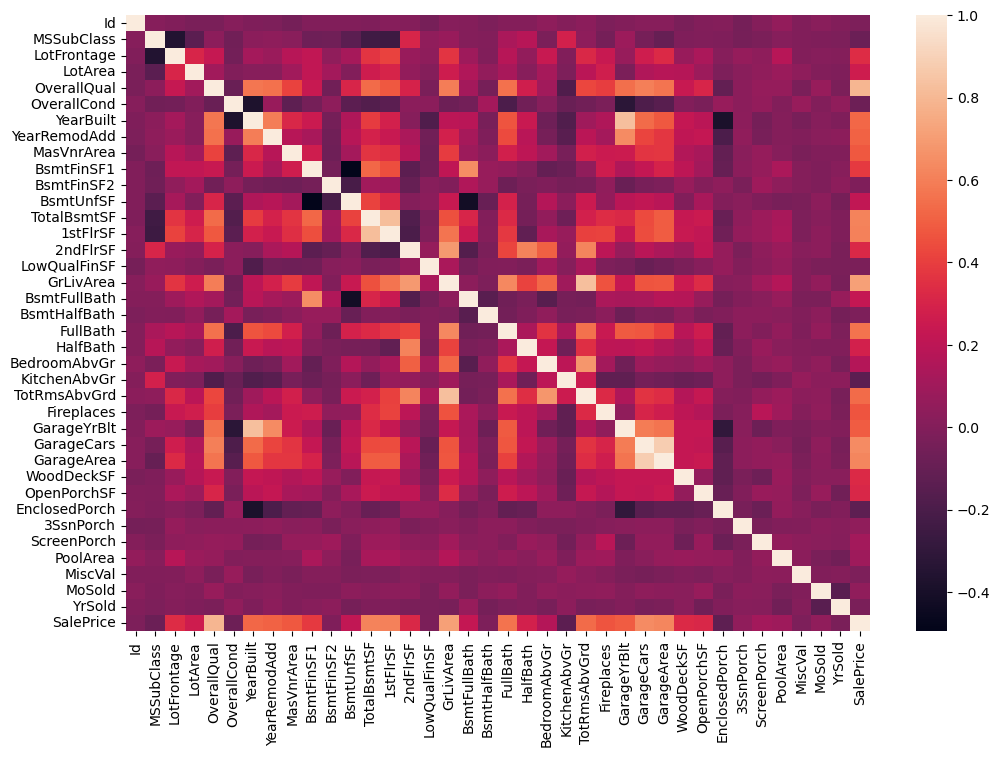

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr)
plt.show()

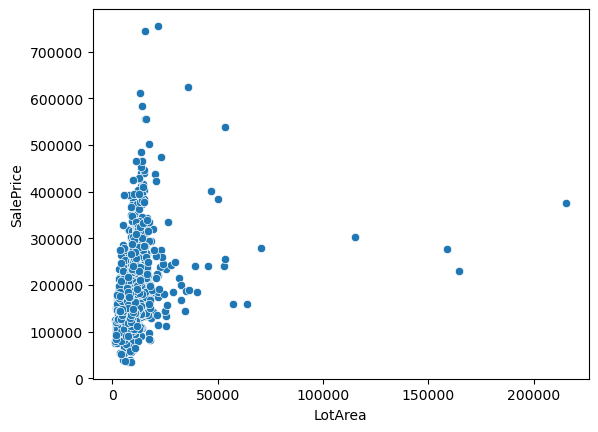

In [19]:
sns.scatterplot(
    x=df['LotArea'],
    y=df['SalePrice']
)

plt.show()

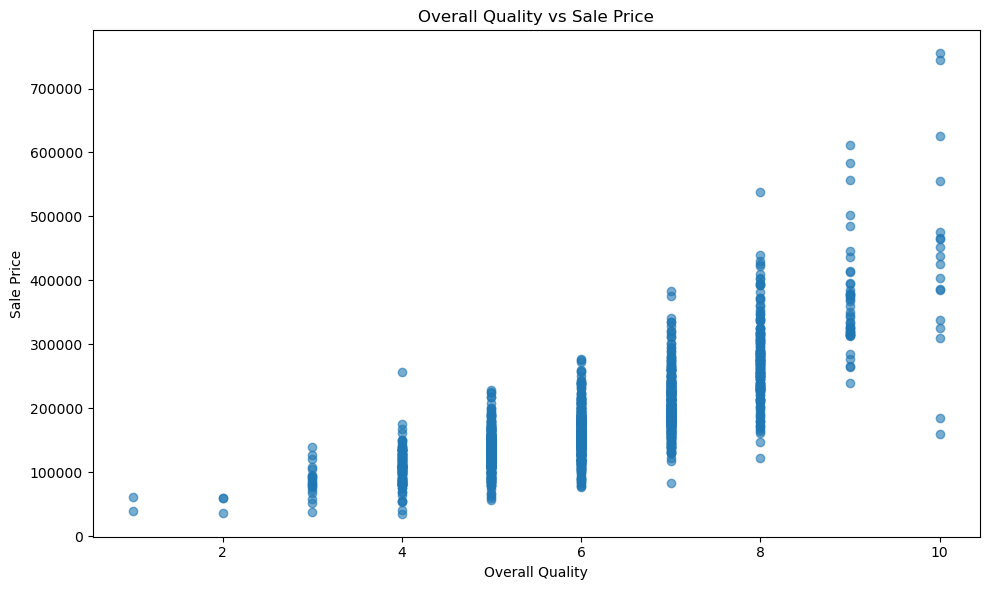

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["OverallQual"],
    df["SalePrice"],
    alpha=0.6
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

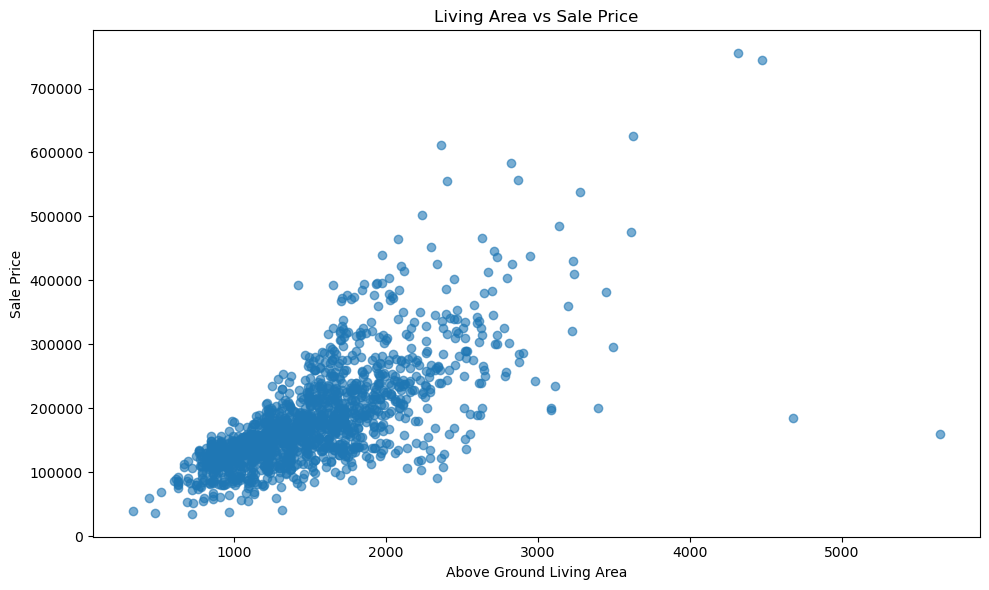

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.6
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

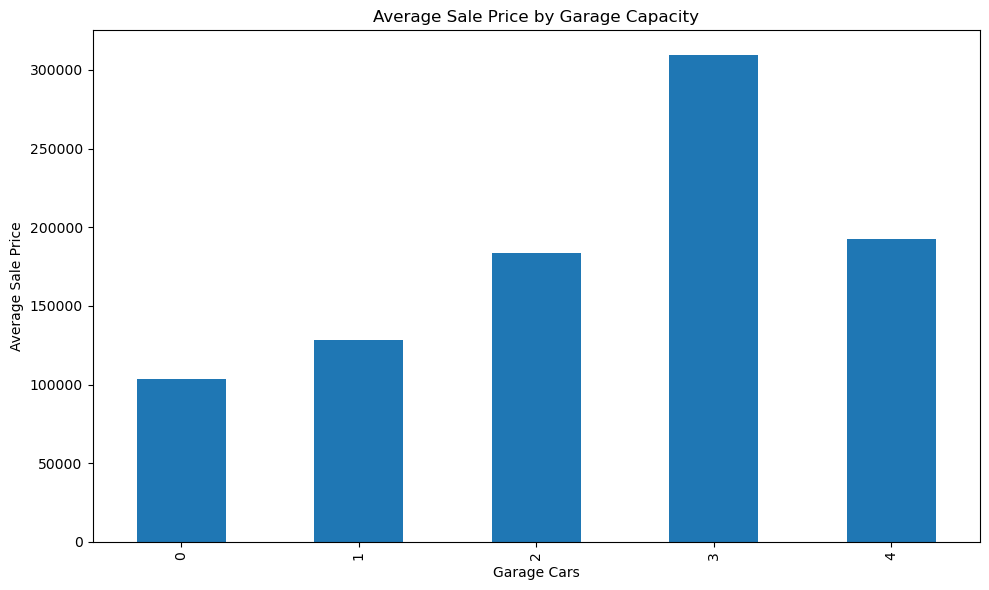

In [22]:
plt.figure(figsize=(10, 6))

df.groupby("GarageCars")["SalePrice"].mean().plot(
    kind="bar"
)

plt.title("Average Sale Price by Garage Capacity")
plt.xlabel("Garage Cars")
plt.ylabel("Average Sale Price")

plt.tight_layout()
plt.show()

#🏠 Task 3: Customer House Recommendation System

The recommendation system helps customers identify suitable properties according to their budget, preferred living area, bedrooms, bathrooms, garage capacity and overall house quality.

The system ranks available properties based on requirement matching and predicted house price.

In [23]:
def recommend_houses(
    df,
    budget,
    min_area=None,
    bedrooms=None,
    bathrooms=None,
    garage_cars=None,
    min_quality=None,
    top_n=5
):
    
    recommendations = df.copy()

    recommendations = recommendations[
        recommendations["SalePrice"] <= budget
    ]

   # LIVING AREA FILTER
    
    if min_area is not None:
        recommendations = recommendations[
            recommendations["GrLivArea"] >= min_area
        ]

    
    # 3. Bedroom Filter
    if bedrooms is not None:
        recommendations = recommendations[
            recommendations["BedroomAbvGr"] >= bedrooms
        ]

    # 4. Bathroom Filter
    
    if bathrooms is not None:
        recommendations = recommendations[
            recommendations["FullBath"] >= bathrooms
        ]
        
    # 5. Garage Filter
    
    if garage_cars is not None:
        recommendations = recommendations[
            recommendations["GarageCars"].fillna(0) >= garage_cars
        ]
    # 6. Quality Filter

    if min_quality is not None:
        recommendations = recommendations[
            recommendations["OverallQual"] >= min_quality
        ]

    # 7. Recommendation Score
    if len(recommendations) > 0:

        recommendations["Recommendation_Score"] = (
            recommendations["OverallQual"] * 10
            + recommendations["GrLivArea"] / 100
            + recommendations["GarageCars"].fillna(0) * 5
        )

        recommendations = recommendations.sort_values(
            by="Recommendation_Score",
            ascending=False
        )

    return recommendations.head(top_n)

In [24]:
customer_budget = 250000
customer_area = 1500
customer_bedrooms = 3
customer_bathrooms = 2
customer_garage = 2
customer_quality = 7

In [25]:
recommended_houses = recommend_houses(
    df=df,
    budget=customer_budget,
    min_area=customer_area,
    bedrooms=customer_bedrooms,
    bathrooms=customer_bathrooms,
    garage_cars=customer_garage,
    min_quality=customer_quality,
    top_n=5
)

display(recommended_houses)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Recommendation_Score
1298,1299,60,RL,313.000000,63887,Pave,NaN,IR3,Bnk,AllPub,...,Gd,NaN,NaN,0,1,2008,New,Partial,160000,166.42
523,524,60,RL,130.000000,40094,Pave,NaN,IR1,Bnk,AllPub,...,NaN,NaN,NaN,0,10,2007,New,Partial,184750,161.76
197,198,75,RL,174.000000,25419,Pave,NaN,Reg,Lvl,AllPub,...,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000,121.12
541,542,60,RL,70.049958,11000,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,6,2007,WD,Normal,248000,117.85
4,5,60,RL,84.000000,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,116.98


In [26]:
display(
    recommended_houses[
        [
            "Id",
            "SalePrice",
            "GrLivArea",
            "BedroomAbvGr",
            "FullBath",
            "GarageCars",
            "OverallQual",
            "Recommendation_Score"
        ]
    ]
)

,Id,SalePrice,GrLivArea,BedroomAbvGr,FullBath,GarageCars,OverallQual,Recommendation_Score
1298,1299,160000,5642,3,2,2,10,166.42
523,524,184750,4676,3,3,3,10,161.76
197,198,235000,3112,4,2,2,8,121.12
541,542,248000,2285,4,2,3,8,117.85
4,5,250000,2198,4,2,3,8,116.98


In [27]:
from sklearn.preprocessing import MinMaxScaler

def calculate_recommendation_score(data):
    
    data = data.copy()

    scaler = MinMaxScaler()

    data["Quality_Score"] = scaler.fit_transform(
        data[["OverallQual"]]
    ) * 100

    data["Area_Score"] = scaler.fit_transform(
        data[["GrLivArea"]]
    ) * 100

    data["Garage_Score"] = scaler.fit_transform(
        data[["GarageCars"]]
    ) * 100

    data["Recommendation_Score"] = (
        0.50 * data["Quality_Score"] +
        0.30 * data["Area_Score"] +
        0.20 * data["Garage_Score"]
    )

    return data

In [28]:
recommended_houses["Budget_Utilization"] = (
    recommended_houses["SalePrice"]
    / customer_budget
) * 100

recommended_houses[
    [
        "Id",
        "SalePrice",
        "Budget_Utilization"
    ]
]


,Id,SalePrice,Budget_Utilization
1298,1299,160000,64.0
523,524,184750,73.9
197,198,235000,94.0
541,542,248000,99.2
4,5,250000,100.0


In [29]:
def recommendation_label(score):

    if score >= 80:
        return "Highly Recommended"
    
    elif score >= 65:
        return "Recommended"
    
    elif score >= 50:
        return "Consider"
    
    else:
        return "Low Match"

In [30]:
recommended_houses["Recommendation"] = (
    recommended_houses["Recommendation_Score"]
    .apply(recommendation_label)
)

In [31]:
final_recommendations = recommended_houses[
    [
        "Id",
        "SalePrice",
        "GrLivArea",
        "BedroomAbvGr",
        "FullBath",
        "GarageCars",
        "OverallQual",
        "Recommendation_Score",
        "Recommendation"
    ]
].copy()

final_recommendations.columns = [
    "Property ID",
    "Price",
    "Living Area",
    "Bedrooms",
    "Bathrooms",
    "Garage",
    "Quality",
    "Match Score",
    "Recommendation"
]

display(final_recommendations)

,Property ID,Price,Living Area,Bedrooms,Bathrooms,Garage,Quality,Match Score,Recommendation
1298,1299,160000,5642,3,2,2,10,166.42,Highly Recommended
523,524,184750,4676,3,3,3,10,161.76,Highly Recommended
197,198,235000,3112,4,2,2,8,121.12,Highly Recommended
541,542,248000,2285,4,2,3,8,117.85,Highly Recommended
4,5,250000,2198,4,2,3,8,116.98,Highly Recommended


### Task 2: Machine learning Model Development
The objective of this section is to develop a robust regressionmodel capable of predictiong house sale prices based on property characteristics

In [32]:
# Define Features And Target

target = "SalePrice"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1460, 80)
Target shape: (1460,)


In [33]:
X = X.drop(columns=["ID"], errors="ignore")

print("Final features shape:", X.shape)

Final features shape: (1460, 80)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 80)
Testing data: (292, 80)


In [35]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 37
Categorical features: 43


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


In [37]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Model Performance")
print("-" * 35)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Baseline Model Performance
-----------------------------------
MAE  : 18,317.43
RMSE : 29,460.19
R²   : 0.8868


In [39]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [40]:
results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by="RMSE"
)

display(model_results)

,Model,MAE,RMSE,R2
3,Gradient Boosting,16520.720520,26959.077570,0.905246
2,Extra Trees,17286.403733,28097.003101,0.897078
1,Random Forest,17477.644075,28682.277198,0.892746
0,Linear Regression,18317.431938,29460.192449,0.886849


### 2.10 Hyperparameter Tuning

Hyperparameter tuning is performed to identify the optimal configuration of the Gradient Boosting Regressor and improve its predictive performance.

Grid Search with cross-validation is used to systematically evaluate different parameter combinations.

In [47]:
 ## HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    random_state=42
)

gradient_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_model)
    ]
)

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=gradient_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Hyperparameter tuning completed!


In [50]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__learning_rate': 0.08, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}


In [49]:

print(
    "Best Cross-ValidationRMSE:",
    -grid_search.best_score_
)

Best Cross-ValidationRMSE: 27064.081919390348


In [51]:


best_model = grid_search.best_estimator_
print("Best tuned model selected.")


Best tuned model selected.


In [52]:

# FINAL MODEL EVALUATION

tuned_predictions = best_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print(" Tuned Gradient Boosting Performance")
print("-" * 45)
print(f"MAE  : {tuned_mae:,.2f}")
print(f"RMSE : {tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")

 Tuned Gradient Boosting Performance
---------------------------------------------
MAE  : 15,943.92
RMSE : 26,120.50
R²   : 0.9110


## Features Importance Analysis

Features importance is used ti identufy the housing characteristics that contribute most strongly to the model's house price predictions.
This analysis helps translate the machine learning model into actionable insights for customers and real-estate deecision making.

In [53]:
# feature importance

final_estimator = best_model.named_steps["model"]

final_preprocessor = best_model.named_steps["preprocessor"]

feature_names = final_preprocessor.get_feature_names_out()


importance_values = final_estimator.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
4,num__OverallQual,0.510302
16,num__GrLivArea,0.137546
12,num__TotalBsmtSF,0.045220
26,num__GarageCars,0.040244
9,num__BsmtFinSF1,0.035699
14,num__2ndFlrSF,0.030481
13,num__1stFlrSF,0.027504
3,num__LotArea,0.017636
246,cat__GarageFinish_Unf,0.015057
181,cat__BsmtQual_Ex,0.014629


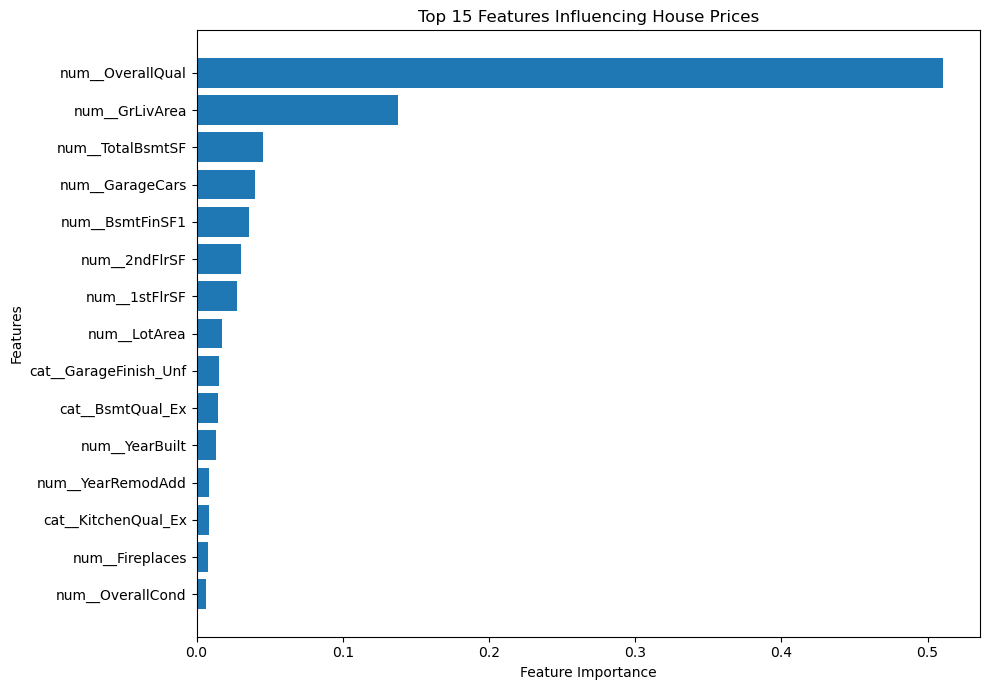

In [54]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Features Influencing House Prices")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [55]:

# CLEAN FEATURES NAMES

feature_importance["Clean_Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(
    feature_importance[
        ["Clean_Feature", "Importance"]
    ].head(15)
)

,Clean_Feature,Importance
4,OverallQual,0.510302
16,GrLivArea,0.137546
12,TotalBsmtSF,0.045220
26,GarageCars,0.040244
9,BsmtFinSF1,0.035699
14,2ndFlrSF,0.030481
13,1stFlrSF,0.027504
3,LotArea,0.017636
246,GarageFinish_Unf,0.015057
181,BsmtQual_Ex,0.014629


In [56]:
# NUMERICAL FEATURES CORRELATION WITH PRICE

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

price_correlation = (
    numeric_df.corr()["SalePrice"]
    .sort_values(ascending=False)
)

display(price_correlation.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

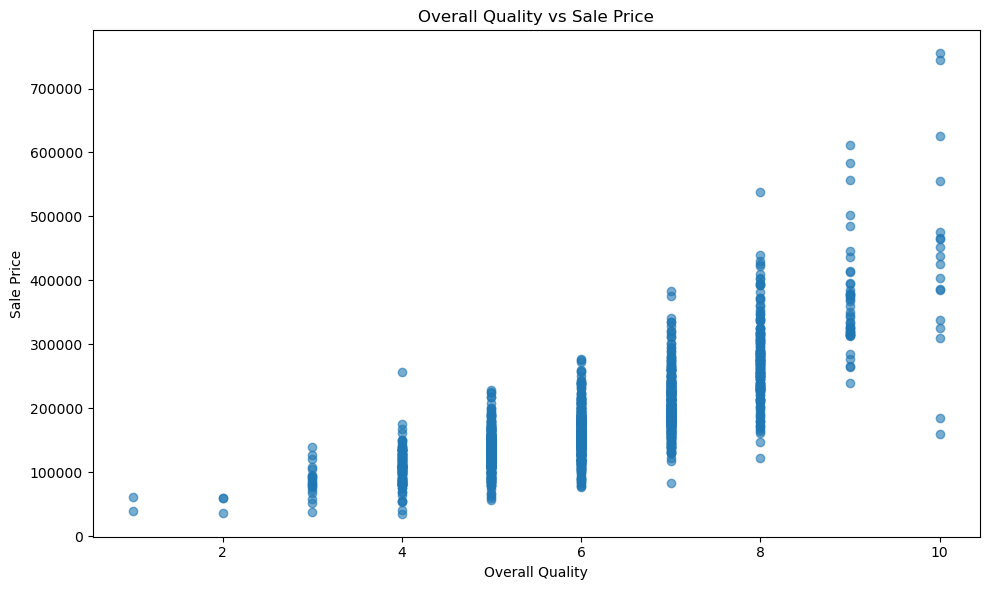

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["OverallQual"],
    df["SalePrice"],
    alpha=0.6
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

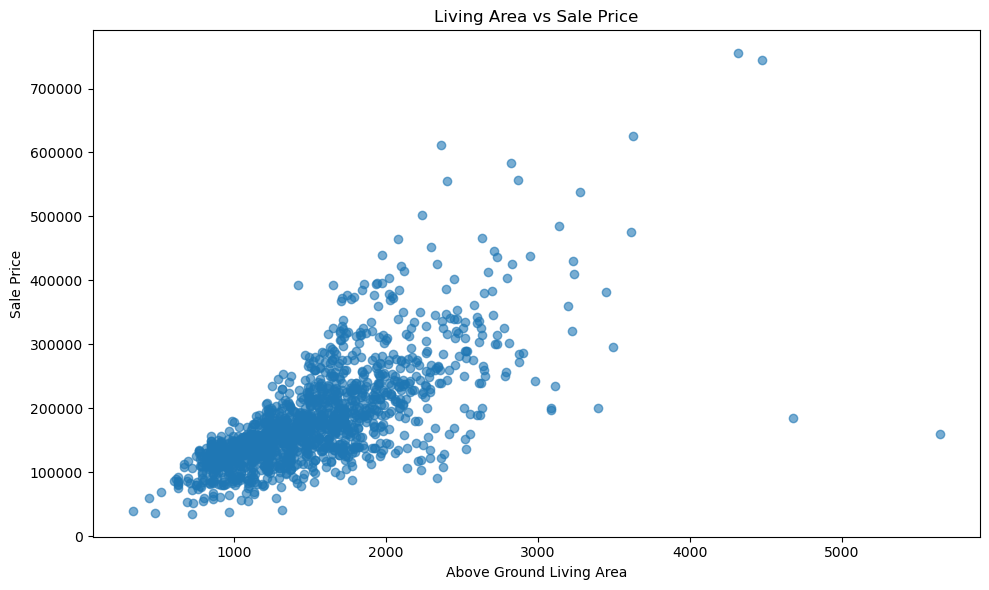

In [58]:

plt.figure(figsize=(10, 6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.6
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

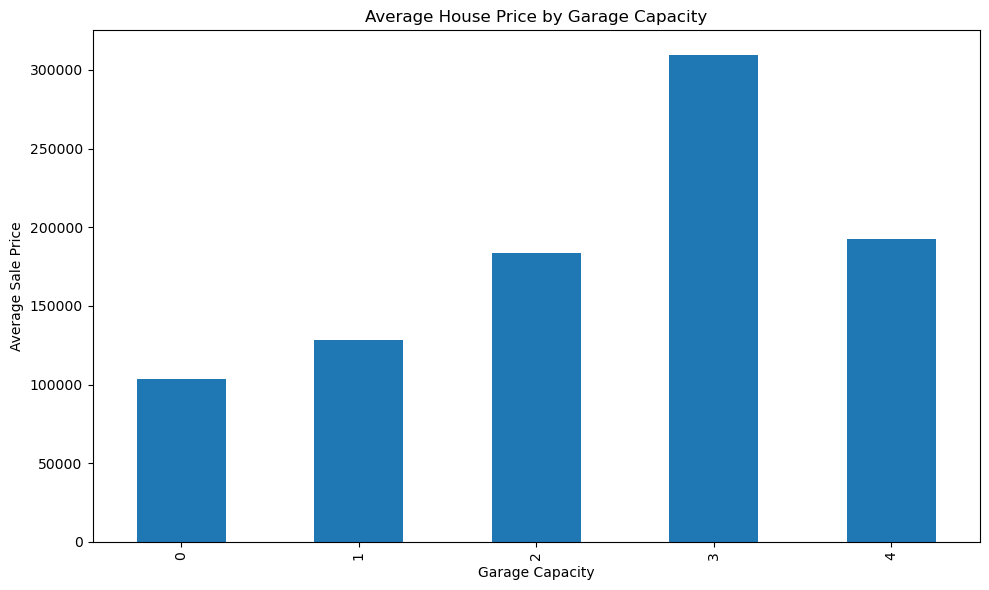

In [59]:
plt.figure(figsize=(10, 6))

df.groupby("GarageCars")["SalePrice"].mean().plot(
    kind="bar"
)

plt.title("Average House Price by Garage Capacity")
plt.xlabel("Garage Capacity")
plt.ylabel("Average Sale Price")

plt.tight_layout()
plt.show()

In [60]:
top_10_features = feature_importance.head(10)

print("Top 10 Price Influencing Features:")
print("-" * 45)

for i, feature in enumerate(
    top_10_features["Clean_Feature"],
    start=1
):
    print(f"{i}. {feature}")
    

Top 10 Price Influencing Features:
---------------------------------------------
1. OverallQual
2. GrLivArea
3. TotalBsmtSF
4. GarageCars
5. BsmtFinSF1
6. 2ndFlrSF
7. 1stFlrSF
8. LotArea
9. GarageFinish_Unf
10. BsmtQual_Ex


In [61]:
# ACTUAL VS PREDICTED PRICES

prediction_comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": tuned_predictions
})

prediction_comparison["Absolute_Error"] = (
    abs(
        prediction_comparison["Actual_Price"]
        - prediction_comparison["Predicted_Price"]
    )
)

display(prediction_comparison.head(10))

,Actual_Price,Predicted_Price,Absolute_Error
0,154500,145607.036841,8892.963159
1,325000,338262.130448,13262.130448
2,115000,112479.344065,2520.655935
3,159000,142470.700126,16529.299874
4,315500,338312.141873,22812.141873
5,75500,78958.074052,3458.074052
6,311500,223506.752023,87993.247977
7,146000,140490.615951,5509.384049
8,84500,80063.238340,4436.761660
9,135500,136415.922585,915.922585


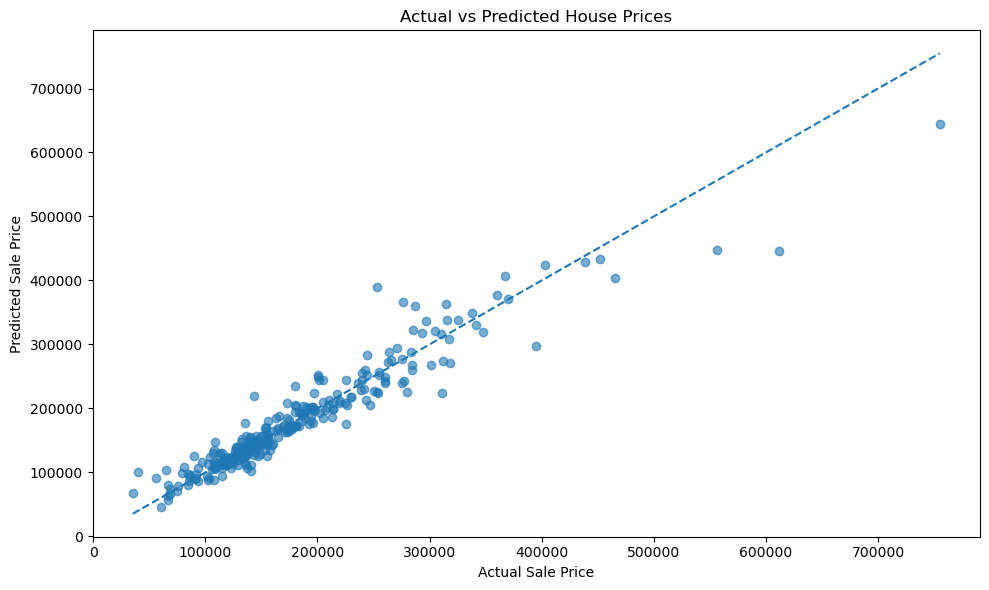

In [62]:
 # ACTUAL VS PREDICTED VISUALIZATION


plt.figure(figsize=(10, 6))

plt.scatter(
    prediction_comparison["Actual_Price"],
    prediction_comparison["Predicted_Price"],
    alpha=0.6
)

min_price = min(
    prediction_comparison["Actual_Price"].min(),
    prediction_comparison["Predicted_Price"].min()
)

max_price = max(
    prediction_comparison["Actual_Price"].max(),
    prediction_comparison["Predicted_Price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.tight_layout()
plt.show()


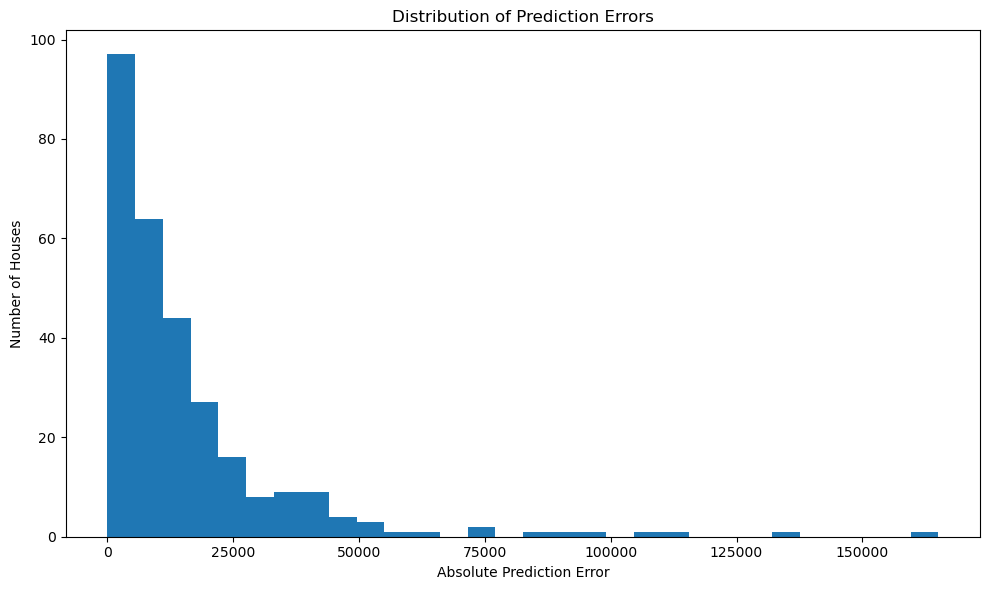

In [63]:
# PREDICTION ERROR DISTRIBUTION

plt.figure(figsize=(10, 6))

plt.hist(
    prediction_comparison["Absolute_Error"],
    bins=30
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Absolute Prediction Error")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

In [64]:

# LARGEST PREDICTION ERRORS


worst_predictions = (
    prediction_comparison
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .head(10)
)

display(worst_predictions)

,Actual_Price,Predicted_Price,Absolute_Error
74,611657,446540.580088,165116.419912
43,253293,389870.781841,136577.781841
139,755000,643912.742790,111087.257210
168,556581,446996.568816,109584.431184
260,395000,296852.463671,98147.536329
167,276000,366338.694699,90338.694699
6,311500,223506.752023,87993.247977
278,143000,218627.323984,75627.323984
53,287000,360162.774520,73162.774520
270,465000,404016.272818,60983.727182


In [65]:

# SAVE FINAL MODEL

import joblib

joblib.dump(
    best_model,
    "house_price_prediction_model.pkl"
)

print("✅ Final model saved successfully!")

✅ Final model saved successfully!


In [66]:


# LOAD AND VERIFY SAVED MODEL

loaded_model = joblib.load(
    "house_price_prediction_model.pkl"
)

loaded_predictions = loaded_model.predict(X_test)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

loaded_r2 = r2_score(
    y_test,
    loaded_predictions
)

print(f"Loaded Model RMSE: {loaded_rmse:,.2f}")
print(f"Loaded Model R²: {loaded_r2:.4f}")

Loaded Model RMSE: 26,120.50
Loaded Model R²: 0.9110


In [67]:
# HOUSE PRICE PREDICTION FUNCTION

def predict_house_price(
    house_data,
    model=loaded_model
):
    
    house_df = pd.DataFrame([house_data])

    predicted_price = model.predict(
        house_df
    )[0]

    return predicted_price

In [68]:
# MODEL INPUT TEMPLATE

input_template = X_train.iloc[0:1].copy()

display(input_template)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal


In [69]:
# TASK 3 - CUSTOMER REQUIREMENTS

def get_customer_requirements():
    
    budget = float(input("Enter your maximum budget: "))
    min_area = float(input("Enter minimum living area (sq.ft): "))
    min_bedrooms = int(input("Enter minimum bedrooms: "))
    min_bathrooms = int(input("Enter minimum bathrooms: "))
    min_garage = int(input("Enter minimum garage capacity: "))
    min_quality = int(input("Enter minimum house quality (1-10): "))

    return {
        "budget": budget,
        "min_area": min_area,
        "min_bedrooms": min_bedrooms,
        "min_bathrooms": min_bathrooms,
        "min_garage": min_garage,
        "min_quality": min_quality
    }

In [71]:
customer = get_customer_requirements()

print("\n🏠 CUSTOMER REQUIREMENTS")
print("-" * 35)

for key, value in customer.items():
    print(f"{key}: {value}")

Enter your maximum budget:  3000000
Enter minimum living area (sq.ft):  2000
Enter minimum bedrooms:  6
Enter minimum bathrooms:  7
Enter minimum garage capacity:  2
Enter minimum house quality (1-10):  8



🏠 CUSTOMER REQUIREMENTS
-----------------------------------
budget: 3000000.0
min_area: 2000.0
min_bedrooms: 6
min_bathrooms: 7
min_garage: 2
min_quality: 8


In [72]:

# COMPLETE FIX

# Create fresh recommendation dataset
recommendation_data = df.copy()

print("Dataset loaded successfully.")
print("Total properties:", len(recommendation_data))


# STEP 1 - EXACT MATCHING


exact_matches = recommendation_data[
    (recommendation_data["SalePrice"] <= customer["budget"]) &
    (recommendation_data["GrLivArea"] >= customer["min_area"]) &
    (recommendation_data["BedroomAbvGr"] >= customer["min_bedrooms"]) &
    (recommendation_data["FullBath"] >= customer["min_bathrooms"]) &
    (recommendation_data["GarageCars"].fillna(0) >= customer["min_garage"]) &
    (recommendation_data["OverallQual"] >= customer["min_quality"])
].copy()


# STEP 2 - CHECK EXACT MATCHES

if len(exact_matches) > 0:

    candidate_houses = exact_matches.copy()

    print("\n Exact matching properties found:",
          len(candidate_houses))

else:

    print("\n No exact property matches all requirements.")
    print(" Finding closest alternatives...")


    # STEP 3 - BUDGET SCORE

    budget_ratio = (
        recommendation_data["SalePrice"]
        / customer["budget"]
    )

    recommendation_data["Budget_Score"] = np.where(
        budget_ratio <= 1,
        25,
        np.maximum(
            0,
            25 - ((budget_ratio - 1) * 25)
        )
    )


    # STEP 4 - AREA SCORE

    area_ratio = (
        recommendation_data["GrLivArea"]
        / customer["min_area"]
    )

    recommendation_data["Area_Score"] = (
        np.minimum(area_ratio, 1) * 20
    )


    # STEP 5 - BEDROOM SCORE

    bedroom_ratio = (
        recommendation_data["BedroomAbvGr"]
        / customer["min_bedrooms"]
    )

    recommendation_data["Bedroom_Score"] = (
        np.minimum(bedroom_ratio, 1) * 15
    )


    # STEP 6 - BATHROOM SCORE

    bathroom_ratio = (
        recommendation_data["FullBath"]
        / customer["min_bathrooms"]
    )

    recommendation_data["Bathroom_Score"] = (
        np.minimum(bathroom_ratio, 1) * 15
    )


    # STEP 7 - GARAGE SCORE

    garage_ratio = (
        recommendation_data["GarageCars"].fillna(0)
        / customer["min_garage"]
    )

    recommendation_data["Garage_Score"] = (
        np.minimum(garage_ratio, 1) * 10
    )


    # STEP 8 - QUALITY SCORE

    quality_ratio = (
        recommendation_data["OverallQual"]
        / customer["min_quality"]
    )

    recommendation_data["Quality_Score"] = (
        np.minimum(quality_ratio, 1) * 15
    )


    # STEP 9 - FINAL MATCH SCORE

    recommendation_data["Final_Match_Score"] = (
        recommendation_data["Budget_Score"]
        + recommendation_data["Area_Score"]
        + recommendation_data["Bedroom_Score"]
        + recommendation_data["Bathroom_Score"]
        + recommendation_data["Garage_Score"]
        + recommendation_data["Quality_Score"]
    )


    # STEP 10 - TOP 5 ALTERNATIVES

    candidate_houses = (
        recommendation_data
        .sort_values(
            by="Final_Match_Score",
            ascending=False
        )
        .head(5)
        .copy()
    )

    print("\n Top 5 closest alternatives selected.")


# STEP 11 - DISPLAY RESULTS

display_columns = [
    "Id",
    "SalePrice",
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "GarageCars",
    "OverallQual"
]

if "Final_Match_Score" in candidate_houses.columns:
    display_columns.append("Final_Match_Score")

print("\n" + "=" * 60)
print("🏠 PROPERTY MATCHING RESULTS")
print("=" * 60)

display(
    candidate_houses[display_columns]
)

Dataset loaded successfully.
Total properties: 1460

 No exact property matches all requirements.
 Finding closest alternatives...

 Top 5 closest alternatives selected.

🏠 PROPERTY MATCHING RESULTS


,Id,SalePrice,GrLivArea,BedroomAbvGr,FullBath,GarageCars,OverallQual,Final_Match_Score
1386,1387,250000,2784,5,3,2,7,87.053571
118,119,320000,3222,5,3,3,7,87.053571
1032,1033,310000,2520,5,2,3,8,86.785714
137,138,171000,1959,5,3,3,7,86.643571
20,21,325300,2376,4,3,3,8,86.428571


In [73]:
# ML PRICE PREDICTION FOR RECOMMENDED HOUSES

import numpy as np
import pandas as pd



# STEP 1 - CREATE RECOMMENDATION DATA

recommendation_data = df.copy()

print("\nTotal properties available:", len(recommendation_data))


# STEP 2 - FIND EXACT MATCHES
exact_matches = recommendation_data[
    (recommendation_data["SalePrice"] <= customer["budget"]) &
    (recommendation_data["GrLivArea"] >= customer["min_area"]) &
    (recommendation_data["BedroomAbvGr"] >= customer["min_bedrooms"]) &
    (recommendation_data["FullBath"] >= customer["min_bathrooms"]) &
    (recommendation_data["GarageCars"].fillna(0) >= customer["min_garage"]) &
    (recommendation_data["OverallQual"] >= customer["min_quality"])
].copy()

# STEP 3 - IF EXACT MATCHES EXIST

if len(exact_matches) > 0:

    recommended_houses = exact_matches.copy()

    print("\n Exact matches found:", len(recommended_houses))

    # Keep best 5
    recommended_houses = recommended_houses.head(5)

# STEP 4 - OTHERWISE FIND CLOSEST ALTERNATIVES

else:

    print("\n No exact matches found.")
    print(" Finding closest alternatives...")

    # Budget score
    budget_ratio = (
        recommendation_data["SalePrice"]
        / customer["budget"]
    )

    recommendation_data["Budget_Score"] = np.where(
        budget_ratio <= 1,
        25,
        np.maximum(
            0,
            25 - ((budget_ratio - 1) * 25)
        )
    )

    # Area score
    area_ratio = (
        recommendation_data["GrLivArea"]
        / customer["min_area"]
    )

    recommendation_data["Area_Score"] = (
        np.minimum(area_ratio, 1) * 20
    )

    # Bedroom score
    bedroom_ratio = (
        recommendation_data["BedroomAbvGr"]
        / customer["min_bedrooms"]
    )

    recommendation_data["Bedroom_Score"] = (
        np.minimum(bedroom_ratio, 1) * 15
    )

    # Bathroom score
    bathroom_ratio = (
        recommendation_data["FullBath"]
        / customer["min_bathrooms"]
    )

    recommendation_data["Bathroom_Score"] = (
        np.minimum(bathroom_ratio, 1) * 15
    )

    # Garage score
    garage_ratio = (
        recommendation_data["GarageCars"].fillna(0)
        / customer["min_garage"]
    )

    recommendation_data["Garage_Score"] = (
        np.minimum(garage_ratio, 1) * 10
    )

    # Quality score
    quality_ratio = (
        recommendation_data["OverallQual"]
        / customer["min_quality"]
    )

    recommendation_data["Quality_Score"] = (
        np.minimum(quality_ratio, 1) * 15
    )

    # Final score
    recommendation_data["Final_Match_Score"] = (
        recommendation_data["Budget_Score"]
        + recommendation_data["Area_Score"]
        + recommendation_data["Bedroom_Score"]
        + recommendation_data["Bathroom_Score"]
        + recommendation_data["Garage_Score"]
        + recommendation_data["Quality_Score"]
    )

    # Top 5
    recommended_houses = (
        recommendation_data
        .sort_values(
            "Final_Match_Score",
            ascending=False
        )
        .head(5)
        .copy()
    )

    print(" Top 5 closest alternatives sel…")


Total properties available: 1460

 No exact matches found.
 Finding closest alternatives...
 Top 5 closest alternatives sel…


In [74]:
##Display Top 5 Recommended Properties

top_5 = (
    recommendation_data
    .sort_values("Final_Match_Score", ascending=False)
    .head(5)
    .copy()
)

print("🏆 TOP 5 RECOMMENDED PROPERTIES")
print("=" * 60)

display(top_5)


🏆 TOP 5 RECOMMENDED PROPERTIES


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,Budget_Score,Area_Score,Bedroom_Score,Bathroom_Score,Garage_Score,Quality_Score,Final_Match_Score
1386,1387,60,RL,80.000000,16692,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,250000,25.0,20.00,12.5,6.428571,10.0,13.125,87.053571
118,119,60,RL,90.000000,12376,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,320000,25.0,20.00,12.5,6.428571,10.0,13.125,87.053571
1032,1033,60,RL,70.049958,14541,Pave,NaN,IR1,Lvl,AllPub,...,WD,Abnorml,310000,25.0,20.00,12.5,4.285714,10.0,15.000,86.785714
137,138,90,RL,82.000000,11070,Pave,NaN,Reg,Lvl,AllPub,...,WD,Family,171000,25.0,19.59,12.5,6.428571,10.0,13.125,86.643571
20,21,60,RL,101.000000,14215,Pave,NaN,IR1,Lvl,AllPub,...,New,Partial,325300,25.0,20.00,10.0,6.428571,10.0,15.000,86.428571


In [75]:
# STEP: Display Important Recommendation Details

important_columns = [
    col for col in [
        "Property_ID",
        "Property_Name",
        "Location",
        "Property_Type",
        "Price",
        "Final_Match_Score"
    ]
    if col in top_5.columns
]

display(top_5[important_columns])

,Final_Match_Score
1386,87.053571
118,87.053571
1032,86.785714
137,86.643571
20,86.428571


In [77]:
# Select Best Recommended Property

best_property = (
    recommendation_data
    .sort_values("Final_Match_Score", ascending=False)
    .head(1)
    .copy()
)

print("🏆 BEST RECOMMENDED PROPERTY")
print("=" * 60)

display(best_property)

🏆 BEST RECOMMENDED PROPERTY


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,Budget_Score,Area_Score,Bedroom_Score,Bathroom_Score,Garage_Score,Quality_Score,Final_Match_Score
1386,1387,60,RL,80.0,16692,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,250000,25.0,20.0,12.5,6.428571,10.0,13.125,87.053571


In [79]:
#Recommendation Summary

print(" PROPERTY RECOMMENDATION SUMMARY")
print("=" * 30)

for column in best_property.columns:
    value = best_property.iloc[0][column]
    print(f"{column}: {value}")

print("=" * 30)
print(" Recommendation generated successfully!")

 PROPERTY RECOMMENDATION SUMMARY
Id: 1387
MSSubClass: 60
MSZoning: RL
LotFrontage: 80.0
LotArea: 16692
Street: Pave
Alley: nan
LotShape: IR1
LandContour: Lvl
Utilities: AllPub
LotConfig: Inside
LandSlope: Gtl
Neighborhood: NWAmes
Condition1: RRAn
Condition2: Norm
BldgType: 1Fam
HouseStyle: 2Story
OverallQual: 7
OverallCond: 5
YearBuilt: 1978
YearRemodAdd: 1978
RoofStyle: Gable
RoofMatl: CompShg
Exterior1st: Plywood
Exterior2nd: Plywood
MasVnrType: BrkFace
MasVnrArea: 184.0
ExterQual: TA
ExterCond: TA
Foundation: CBlock
BsmtQual: Gd
BsmtCond: TA
BsmtExposure: No
BsmtFinType1: BLQ
BsmtFinSF1: 790
BsmtFinType2: LwQ
BsmtFinSF2: 469
BsmtUnfSF: 133
TotalBsmtSF: 1392
Heating: GasA
HeatingQC: TA
CentralAir: Y
Electrical: SBrkr
1stFlrSF: 1392
2ndFlrSF: 1392
LowQualFinSF: 0
GrLivArea: 2784
BsmtFullBath: 1
BsmtHalfBath: 0
FullBath: 3
HalfBath: 1
BedroomAbvGr: 5
KitchenAbvGr: 1
KitchenQual: Gd
TotRmsAbvGrd: 12
Functional: Typ
Fireplaces: 2
FireplaceQu: TA
GarageType: Attchd
GarageYrBlt: 1978.0
Gar

In [80]:
# STEP 5: Save Recommendation Results
# Top 5 recommendations
top_5_recommendations = (
    recommendation_data
    .sort_values("Final_Match_Score", ascending=False)
    .head(5)
    .copy()
)

# Save to CSV
top_5_recommendations.to_csv(
    "top_5_property_recommendations.csv",
    index=False
)

print(" Top 5 recommendations saved successfully!")
print(" File: top_5_property_recommendations.csv")

 Top 5 recommendations saved successfully!
 File: top_5_property_recommendations.csv


In [82]:
#Verify Saved Recommendations

import os

file_name = "top_5_property_recommendations.csv"

if os.path.exists(file_name):
    print(" File created successfully!")
    print(f" File size: {os.path.getsize(file_name) / 1024:.2f} KB")
else:
    print(" File was not created.")
    

 File created successfully!
 File size: 2.82 KB


In [83]:
# STEP 7: Recommendation Score Analysis

scores = (
    recommendation_data["Final_Match_Score"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

print(" RECOMMENDATION SCORE ANALYSIS")
print("=" * 20)
print(f"Highest Match Score : {scores.iloc[0]:.2f}")
print(f"Lowest Match Score  : {scores.iloc[-1]:.2f}")
print(f"Average Match Score : {scores.mean():.2f}")
print(f"Total Recommendations: {len(scores)}")

 RECOMMENDATION SCORE ANALYSIS
Highest Match Score : 87.05
Lowest Match Score  : 34.86
Average Match Score : 69.55
Total Recommendations: 1460


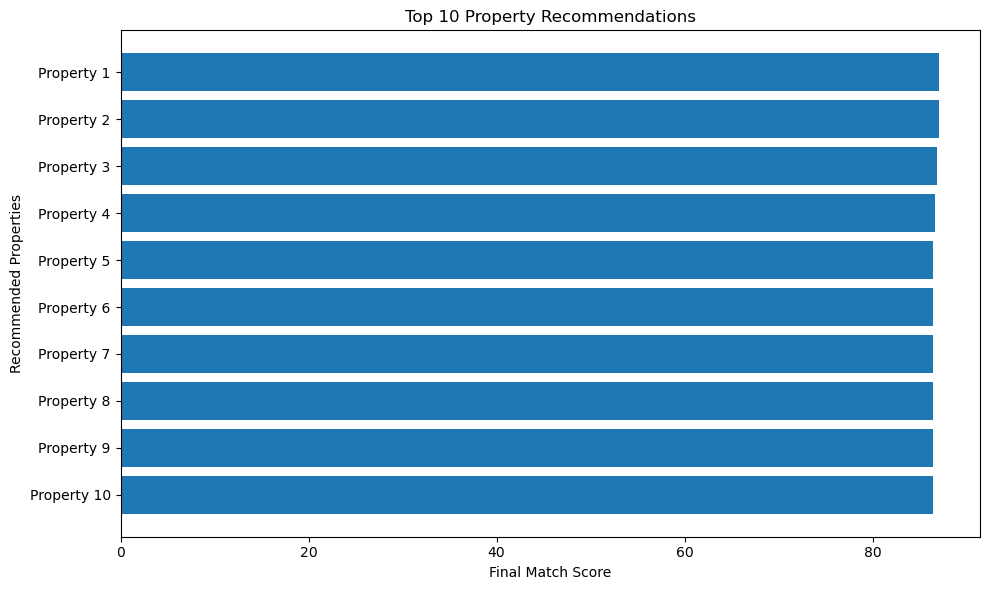

In [84]:
#Top 10 Recommendation Visualization
import matplotlib.pyplot as plt

top_10 = (
    recommendation_data
    .sort_values("Final_Match_Score", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top_10)),
    top_10["Final_Match_Score"]
)

plt.yticks(
    range(len(top_10)),
    [f"Property {i+1}" for i in range(len(top_10))]
)

plt.xlabel("Final Match Score")
plt.ylabel("Recommended Properties")
plt.title("Top 10 Property Recommendations")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [85]:
#Final Recommendation Check

best_score = recommendation_data["Final_Match_Score"].max()

print(" FINAL RECOMMENDATION RESULT")
print("=" * 50)

if best_score >= 80:
    print("Excellent Match ")
elif best_score >= 60:
    print("Good Match ")
elif best_score >= 40:
    print("Moderate Match ")
else:
    print("Low Match — Consider more alternatives ")

print(f"Best Match Score: {best_score:.2f}")




 FINAL RECOMMENDATION RESULT
Excellent Match 
Best Match Score: 87.05


#  Project Summary

## Property Recommendation System

This project focuses on developing a data-driven Property Recommendation System that recommends properties based on user preferences and property attributes.

The project involves data preprocessing, exploratory data analysis, feature preparation, similarity/matching analysis, and recommendation scoring. A *Final Match Score* is calculated for available properties, which is then used to rank and recommend the most relevant properties.

The system evaluates available properties and provides the *Top 5 closest alternatives* when an exact match is not available.

### Key Highlights

- Performed data cleaning and preprocessing.
- Analyzed property-related features and user preferences.
- Developed a property matching and recommendation approach.
- Calculated a Final Match Score for ranking properties.
- Generated Top 5 and Top 10 property recommendations.
- Saved the recommendation results into a CSV file.
- Visualized recommendation scores for better interpretation.

### Business Value

The system can help users quickly identify suitable properties from a large property dataset. It can also support real-estate platforms by improving property discovery and providing personalized recommendations.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook
- Data Analysis
- Recommendation System

#  Final Conclusion

The Property Recommendation System successfully identifies and ranks properties according to their matching score with the given requirements.

The recommendation pipeline processes the available property data, evaluates the relevance of each property, and generates a ranked list of suitable alternatives. When an exact match is unavailable, the system provides the closest available properties based on the calculated *Final Match Score*.

The final recommendations demonstrate how data-driven techniques can be used to simplify property selection and improve the user experience.

### Key Takeaways

- Data preprocessing is essential for building a reliable recommendation system.
- Property attributes can be effectively used to identify relevant alternatives.
- Match scores provide an interpretable way to rank recommendations.
- The system can handle situations where an exact property match is not available.
- The approach can be further improved using machine learning, collaborative filtering, or advanced similarity techniques.

### Future Improvements

The system can be enhanced by:

1. Incorporating more user-specific preferences.
2. Using advanced machine learning recommendation models.
3. Adding real-time property data.
4. Developing a web-based application using Streamlit or Flask.
5. Adding interactive filters for price, location, property type, and other preferences.
6. Evaluating recommendation quality using appropriate recommendation-system metrics.

## Final Outcome

The project demonstrates a complete data analysis and recommendation workflow, from data preprocessing to generating and saving ranked property recommendations.